# 복지 직권주의 추천 + 마을 방송국 (Welfare Proactive Advisor) — v2

**웹 서비스용 폼 입력 + DB 매칭엔진(`match_welfare` RPC)** 으로 재구성한 버전.
신청주의의 사각지대를 줄이기 위한 **LangGraph 하이브리드** 시스템. 코어(복지 DB · 결정론 자격 게이트 · 상담 의도추출 · 쉬운말 변환)를 두 그래프가 공유합니다.

- **시민 그래프**(hybrid): **구조화 폼 입력**(성별·출생연도·주소·가구형태·소득구간·거주형태 + 체크리스트) → `intake`(폼→profile) → **결정론 하드게이트 + 정밀 스코어링(RPC)** → 균일 카드(확신도 라벨) → 상담형 피드백 루프(자연어→의도매칭) → (디지털 취약 시) 복지사 **핸드오프(HITL)**
- **방송 그래프**(workflow): 지역 demographic → 적합 제도 선별 → **Map-Reduce(`Send()`)** 멘트 생성 → 마을 방송 대본 합치기

> 매칭은 단순 RAG가 아니라 **연령·소득·성별 하드 게이트 + 특성 플래그 스코어 + 분야/키워드/생애주기/지역 가점**(Supabase `match_welfare` 함수)으로 자격 미달 제도를 구조적으로 배제하고 전체 적격 풀에서 랭킹합니다.

## Setup

1. `uv`로 가상환경 + 커널 등록 후 커널 **"Welfare Advisor (uv)"** 선택.
2. **키 파일**(`_env`/`.env`/`env.txt`)을 노트북과 같은 폴더에. 최소 `OPENAI_API_KEY` + (권장) `SUPABASE_URL`,`SUPABASE_SERVICE_KEY`.
3. 데이터 소스:
   - **Supabase(권장)**: `match_welfare` RPC + 두 테이블이 배포된 프로젝트. 폼 한 번 → RPC 한 번으로 랭킹.
   - **CSV 폴백**: `welfare_services_rows.csv`,`welfare_support_conditions_rows.csv` 를 `WELFARE_CSV_DIR`(기본 `./data`)에. RPC 없이 동일 로직을 파이썬으로 수행.
4. 웹폼 입력 규약은 `welfare_form_spec.md` 참고. 데모는 폼 payload 를 초기 상태로 주입합니다.

> ⚠️ 키 파일은 git 커밋 금지(`.gitignore`).

In [1]:
import os, json, sqlite3, operator
from typing import TypedDict, Annotated, Optional
from datetime import date
from dotenv import load_dotenv

# 키는 코드에 노출하지 않는다. 노트북과 같은 경로의 _env/.env/env.txt 에서 로드.
for _envfile in ("_env", ".env", "env.txt"):
    if os.path.exists(_envfile):
        load_dotenv(_envfile, override=True)
        print(f"env loaded: {_envfile}")
        break
else:
    print("env 파일을 찾지 못함 — 시스템 환경변수를 사용합니다")

import pandas as pd
from pydantic import BaseModel, Field

from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.types import interrupt, Command, Send
from langgraph.checkpoint.sqlite import SqliteSaver

print("imports OK")

env loaded: .env
imports OK


In [2]:
# --- LLM + observability ---
MODEL = os.getenv("OPENAI_MODEL", "gpt-4o-mini")
llm = init_chat_model(MODEL, temperature=0)

try:
    from langfuse.langchain import CallbackHandler
    langfuse_handler = CallbackHandler()
    CALLBACKS = [langfuse_handler]
    print(f"LLM={MODEL}, LangFuse=ON")
except Exception as e:
    langfuse_handler = None
    CALLBACKS = []
    print(f"LLM={MODEL}, LangFuse=OFF ({type(e).__name__})")

def ask_llm(messages):
    return llm.invoke(messages, config={"callbacks": CALLBACKS})

LLM=gpt-4o-mini, LangFuse=ON


## State schema & 상수

`WelfareState` 는 시민 그래프 상태. `form`(웹폼 원본) → `intake` 가 `profile` 로 정규화. `profile` 슬롯(`gender`/`age`/`income_band`/`region_sido`/`characteristics`/`life_stages`/`service_fields`/`keywords`)이 `match_welfare` 입력이 됩니다. 방송 그래프는 집계 관점이라 `BroadcastState` 를 따로 두고 `segments` 만 `operator.add` 로 fan-in.

In [3]:
# === condition 테이블 정형 컬럼 / 상수 ===
CHARACTERISTIC_FLAGS = [
    "multi_cultural", "north_korean_defector", "single_parent", "single_household",
    "multi_child", "no_house", "expecting_parent", "pregnant", "postpartum",
    "farmer", "fisher", "livestock", "forester", "elementary", "middle_school",
    "high_school", "university", "employed", "unemployed", "disabled", "veteran", "illness",
]
INCOME_BANDS = ["50", "75", "100", "200", "over200"]
# 폼에 없이 상담 모드에서만 자연어로 받는 정밀 플래그
CONSULT_FLAGS = [
    "multi_cultural", "north_korean_defector", "farmer", "fisher", "livestock",
    "forester", "veteran", "illness", "employed", "unemployed",
]
# 실제 데이터 기준 21종 분야 (Intent/Consult 가이드 + 카드 매칭)
SERVICE_FIELDS = [
    "생활안정", "생활지원", "서민금융", "농림축산어업", "보육·교육", "보육", "교육",
    "보건·의료", "신체건강", "임신·출산", "입양·위탁", "고용·창업", "일자리",
    "문화·환경", "문화·여가", "에너지", "보호·돌봄", "행정·안전", "주거·자립",
    "주거", "안전·위기",
]

class WelfareState(TypedDict):
    messages: Annotated[list, add_messages]
    mode: str
    form: dict                       # 웹폼 원본 payload
    profile: dict                    # 정규화된 매칭 입력
    candidates: list
    cards: list
    feedback_round: int
    handoff_needed: bool
    handoff_packet: Optional[dict]

class BroadcastState(TypedDict):
    region: dict
    demographic: str
    benefits: list
    benefit: dict
    segments: Annotated[list, operator.add]
    script: str

## 데이터 계층 — 매칭엔진 (Supabase RPC 우선, CSV 폴백)

`DB.match(profile)` 하나로 통일. **Supabase 모드**는 `match_welfare` RPC(하드게이트→정밀 스코어링→전체 풀 랭킹)를 호출하고, **CSV 모드**는 동일 취지의 로직(연령·성별·소득 하드게이트 + 특성 매칭 + 분야/키워드 가점)을 파이썬으로 수행합니다. 두 경로 모두 동일한 카드 스키마를 반환합니다.

In [4]:
# === 데이터 계층 ===
def _truthy(v):
    if isinstance(v, bool): return v
    return str(v).strip().lower() in ("true", "1", "t", "y", "yes")

def _na(v):
    if v is None: return ""
    if isinstance(v, float):
        try:
            import math
            if math.isnan(v): return ""
        except Exception: pass
    s = str(v).strip()
    return "" if s.lower() == "nan" else s

ID_COLS = {"service_id": str}

class WelfareDB:
    def __init__(self):
        self.mode = None; self.sb = None; self.svc = None; self.cond = None
        url = os.getenv("SUPABASE_URL")
        key = (os.getenv("SUPABASE_SERVICE_KEY") or os.getenv("SUPABASE_ANON_KEY")
               or os.getenv("SUPABASE_KEY"))
        if url and key:
            try:
                from supabase import create_client
                self.sb = create_client(url, key)
                self.mode = "supabase"
                print("WelfareDB: Supabase 연결됨 (match_welfare RPC 사용)")
            except Exception as e:
                print(f"WelfareDB: Supabase 실패({e}) → CSV 폴백")
        if self.mode != "supabase":
            d = os.getenv("WELFARE_CSV_DIR", "./data")
            self.svc = pd.read_csv(f"{d}/welfare_services_rows.csv", dtype=ID_COLS, low_memory=False)
            self.cond = pd.read_csv(f"{d}/welfare_support_conditions_rows.csv", dtype=ID_COLS, low_memory=False)
            bool_cols = (CHARACTERISTIC_FLAGS + ["male_eligible", "female_eligible"]
                         + [f"income_band_{b}" for b in INCOME_BANDS])
            for c in bool_cols:
                if c in self.cond.columns:
                    self.cond[c] = self.cond[c].map(_truthy)
            for c in ("age_start", "age_end"):
                if c in self.cond.columns:
                    self.cond[c] = pd.to_numeric(self.cond[c], errors="coerce")
            self.mode = "csv"
            print(f"WelfareDB: CSV 로드 ({len(self.svc)} services / {len(self.cond)} conditions)")

    # ---- 통일 진입점 ----
    def match(self, profile, top=6):
        if self.mode == "supabase":
            p = dict(profile); p["top"] = top
            try:
                rows = self.sb.rpc("match_welfare", {"p": p}).execute().data or []
                return cards_from_rpc(rows, top)
            except Exception as e:
                print(f"RPC 실패({e}) → CSV 폴백 시도")
                if self.svc is None:
                    return []
        gated = self.gate(profile, limit=150)
        region = profile.get("region") or {"sido": profile.get("region_sido")}
        svc_map = self.fetch_services([g["service_id"] for g in gated], region=region)
        return build_cards(gated, svc_map, profile.get("service_fields"),
                           keywords=profile.get("keywords"), top=top)

    # ---- CSV 폴백 로직 ----
    def _cond_candidates(self, profile):
        income = profile.get("income_band"); gender = profile.get("gender")
        df = self.cond
        m = pd.Series(True, index=df.index)
        if income and f"income_band_{income}" in df.columns:
            m &= df[f"income_band_{income}"]
        if gender == "M": m &= df["male_eligible"]
        if gender == "F": m &= df["female_eligible"]
        return df[m].to_dict("records")

    def gate(self, profile, limit=150):
        age = profile.get("age"); chars = set(profile.get("characteristics") or [])
        out = []
        for r in self._cond_candidates(profile):
            a0, a1 = r.get("age_start"), r.get("age_end")
            if age is not None and pd.notna(a0) and pd.notna(a1):
                try:
                    if not (int(float(a0)) <= age <= int(float(a1))):
                        continue
                except (TypeError, ValueError):
                    pass
            svc_chars = {f for f in CHARACTERISTIC_FLAGS if _truthy(r.get(f))}
            matched = chars & svc_chars
            spec = len(svc_chars); narrow = 0 < spec <= 6
            if chars and narrow and not matched:
                continue
            out.append({"service_id": str(r.get("service_id")), "matched": sorted(matched),
                        "narrow": narrow, "income_checked": bool(profile.get("income_band")),
                        "age_checked": age is not None, "score": 1 + len(matched) * 2})
        out.sort(key=lambda x: -x["score"])
        return out[:limit]

    def fetch_services(self, ids, region=None):
        ids = [str(i) for i in ids]
        rows = self.svc[self.svc["service_id"].isin(ids)].to_dict("records")
        sido = (region or {}).get("sido")
        out = {}
        for s in rows:
            rs = _na(s.get("region_sido"))
            if rs and sido and rs != sido:
                continue
            s["_local"] = bool(rs)
            out[str(s.get("service_id"))] = s
        return out

DB = WelfareDB()

WelfareDB: Supabase 연결됨 (match_welfare RPC 사용)


In [5]:
# === 공용 헬퍼: 카드/지역/말투/폼/상담 ===
def _clip(s, n=240):
    s = _na(s).replace("\r", " ").replace("\n", " ").strip()
    return s[:n] + ("…" if len(s) > n else "")

def _confidence(meta):
    if meta["income_checked"] and meta["age_checked"] and (meta["matched"] or not meta["narrow"]):
        return "확실"
    if meta["income_checked"] or meta["age_checked"]:
        return "조건부"
    return "참고"

def cards_from_rpc(rows, top=6):
    """match_welfare RPC 결과 → 균일 카드 스키마."""
    cards = []
    for rank, r in enumerate(rows[:top], 1):
        cards.append({
            "rank": rank,
            "service_name": _na(r.get("service_name")),
            "field": _na(r.get("service_field")),
            "local": bool(r.get("is_local")),
            "support": _clip(r.get("support_content")),
            "apply_method": _clip(r.get("apply_method"), 120) or "주민센터 방문/문의",
            "receiving_agency": _na(r.get("receiving_agency")) or "주민센터",
            "contact": _na(r.get("contact")),
            "deadline": _clip(r.get("apply_deadline"), 80) or "상시",
            "detail_url": _na(r.get("detail_url")),
            "confidence": _na(r.get("confidence")) or "참고",
            "matched": r.get("matched") or [],
        })
    return cards

def build_cards(gated, svc_map, service_fields, keywords=None, top=6):
    """CSV 폴백용 카드 생성 (RPC와 동일 취지의 가점 랭킹)."""
    want = {f.replace(" ", "") for f in (service_fields or [])}
    kws = [k.strip() for k in (keywords or []) if k and k.strip()]
    rows = []
    for g in gated:
        s = svc_map.get(g["service_id"])
        if not s:
            continue
        sf = {x.replace(" ", "") for x in _na(s.get("service_field")).split(",") if x.strip()}
        field_hit = len(want & sf)
        blob = (_na(s.get("service_name")) + " " + _na(s.get("service_summary")) + " "
                + _na(s.get("support_content"))).lower()
        kw_hit = sum(1 for k in kws if k.lower() in blob)
        rel = field_hit * 6 + kw_hit * 3 + (3 if s.get("_local") else 0) + g["score"] * 0.05
        rows.append((rel, field_hit + kw_hit, g, s))
    if want or kws:
        hits = [r for r in rows if r[1] > 0]
        rows = hits if len(hits) >= 3 else rows
    rows.sort(key=lambda x: -x[0])
    cards = []
    for rank, (rel, fh, g, s) in enumerate(rows[:top], 1):
        cards.append({
            "rank": rank, "service_name": _na(s.get("service_name")),
            "field": _na(s.get("service_field")), "local": bool(s.get("_local")),
            "support": _clip(_na(s.get("support_content")) or s.get("service_summary")),
            "apply_method": _clip(s.get("apply_method"), 120) or "주민센터 방문/문의",
            "receiving_agency": _na(s.get("receiving_agency")) or "주민센터",
            "contact": _na(s.get("contact")),
            "deadline": _clip(s.get("apply_deadline"), 80) or "상시",
            "detail_url": _na(s.get("detail_url")),
            "confidence": _confidence({**g, "matched": g["matched"]}),
            "matched": g["matched"],
        })
    return cards

def render_cards(cards, dialect=None):
    lines = []
    for c in cards:
        tag = "🏠우리동네 " if c["local"] else ""
        lines.append(
            f"[{c['rank']}] {tag}{c['service_name']}  ({c['confidence']})\n"
            f"   - 지원: {c['support']}\n"
            f"   - 신청: {c['apply_method']} / 접수처: {c['receiving_agency']}\n"
            f"   - 문의: {c['contact']}  마감: {c['deadline']}\n"
            f"   - 자세히: {c['detail_url']}")
    return "\n".join(lines) if lines else "(조건에 맞는 제도를 찾지 못했어요)"

# --- 지역 ---
DIALECT_MAP = {
    "충청남도": "충청도", "충청북도": "충청도", "대전광역시": "충청도", "세종특별자치시": "충청도",
    "경상남도": "경상도", "경상북도": "경상도", "대구광역시": "경상도", "부산광역시": "경상도", "울산광역시": "경상도",
    "전라남도": "전라도", "전라북도": "전라도", "전북특별자치도": "전라도", "광주광역시": "전라도",
    "강원특별자치도": "강원도", "제주특별자치도": "제주도",
}
SIDO_LIST = [
    "서울특별시", "부산광역시", "대구광역시", "인천광역시", "광주광역시", "대전광역시", "울산광역시",
    "세종특별자치시", "경기도", "강원특별자치도", "충청북도", "충청남도", "전북특별자치도",
    "전라남도", "경상북도", "경상남도", "제주특별자치도", "강원도", "전라북도",
]
SIDO_ALIAS = {
    "서울": "서울특별시", "부산": "부산광역시", "대구": "대구광역시", "인천": "인천광역시",
    "광주": "광주광역시", "대전": "대전광역시", "울산": "울산광역시", "세종": "세종특별자치시",
    "경기": "경기도", "강원": "강원특별자치도", "충북": "충청북도", "충남": "충청남도",
    "전북": "전북특별자치도", "전남": "전라남도", "경북": "경상북도", "경남": "경상남도", "제주": "제주특별자치도",
}

def parse_region(text):
    import re
    t = (text or "").strip()
    sido = next((s for s in SIDO_LIST if s in t), None)
    if not sido:
        for short, full in SIDO_ALIAS.items():
            if short in t:
                sido = full; break
    rest = t.replace(sido, "") if sido else t
    m = re.search(r"([가-힣]+(?:시|군|구))", rest)
    return {"sido": sido, "sigungu": m.group(1) if m else None}

def _dialect(state):
    prof = state.get("profile") or {}
    sido = prof.get("region_sido") or (prof.get("region") or {}).get("sido") \
           or (state.get("region") or {}).get("sido")
    return DIALECT_MAP.get(sido)

def easy_translate(text, dialect=None):
    sys = ("당신은 복지 안내문을 어르신도 한 번에 이해하도록 아주 쉬운 말로 바꿔주는 도우미입니다. "
           "짧은 존댓말 문장, 어려운 한자어는 풀어쓰고, 숫자·신청처·문의처는 또렷하게 반복하세요.")
    if dialect:
        sys += f" 너무 과하지 않게 {dialect} 말투를 살짝 입혀 친근하게 해주세요."
    return ask_llm([SystemMessage(content=sys), HumanMessage(content=text)]).content

# --- 웹폼 payload → profile (welfare_form_spec.md 계약) ---
def build_profile_from_form(form):
    chars, lifes = set(), set()
    age = None
    by = form.get("birth_year")
    if by:
        try: age = date.today().year - int(by)
        except (TypeError, ValueError): age = None
    income = form.get("income_band") or None
    cl = set(form.get("checklist") or [])
    if "basic_recipient" in cl: income = "50"
    elif "near_poor" in cl and income != "50": income = "75"
    ht = form.get("household_type")
    if ht == "single": chars.add("single_household")
    elif ht == "multichild": chars.add("multi_child")
    if form.get("housing_type") in ("jeonse", "wolse", "etc"): chars.add("no_house")
    if "disabled" in cl: chars.add("disabled")
    if "perinatal" in cl: chars.update(["expecting_parent", "pregnant", "postpartum"])
    if "single_parent" in cl: chars.add("single_parent")
    if "infant" in cl: lifes.add("영유아")
    sido = form.get("region_sido") or None
    sigungu = form.get("region_sigungu") or None
    return {
        "gender": form.get("gender") or None, "age": age, "income_band": income,
        "region_sido": sido, "region_sigungu": sigungu,
        "region": {"sido": sido, "sigungu": sigungu},
        "characteristics": sorted(chars), "life_stages": sorted(lifes),
        "service_fields": [], "keywords": [], "needs_text": "",
    }

# --- 상담 모드: 자연어 → 분야/키워드/추가특성 ---
class ConsultExtract(BaseModel):
    service_fields: list[str] = Field(default_factory=list,
        description=f"관련 복지 분야(여러 개 가능): {SERVICE_FIELDS}")
    keywords: list[str] = Field(default_factory=list, description="핵심 필요 키워드 3~6개")
    characteristics: list[str] = Field(default_factory=list,
        description=f"문장에서 드러난 특성만. 다음 중에서: {CONSULT_FLAGS}")

def extract_consult(consult_text):
    if not consult_text:
        return {"service_fields": [], "keywords": [], "characteristics": []}
    out = llm.with_structured_output(ConsultExtract).invoke(
        [SystemMessage(content="복지 상담 문장에서 분야·키워드·해당 특성을 추출하세요. 특성은 제시된 목록에 있는 것만."),
         HumanMessage(content=consult_text)], config={"callbacks": CALLBACKS})
    return {"service_fields": out.service_fields, "keywords": out.keywords,
            "characteristics": out.characteristics}

def merge_consult(profile, consult):
    p = dict(profile)
    p["service_fields"] = sorted(set(p.get("service_fields") or []) | set(consult.get("service_fields") or []))
    p["keywords"] = sorted(set(p.get("keywords") or []) | set(consult.get("keywords") or []))
    p["characteristics"] = sorted(set(p.get("characteristics") or []) | set(consult.get("characteristics") or []))
    return p

# --- 핸드오프 패킷 ---
def build_packet(state):
    prof = state.get("profile") or {}
    cards = state.get("cards") or []
    return {
        "민원인_요약": {
            "지역": prof.get("region"), "연령": prof.get("age"),
            "소득구간": prof.get("income_band"), "특성": prof.get("characteristics"),
            "필요": prof.get("needs_text"),
        },
        "추천제도": [{"제도명": c["service_name"], "접수처": c["receiving_agency"],
                       "문의": c["contact"], "확신도": c["confidence"]} for c in cards[:5]],
        "막힌_지점": state.get("_stuck", "신청 방법을 어려워함(디지털 취약)"),
    }

def packet_text(packet):
    return json.dumps(packet, ensure_ascii=False, indent=2)

def send_handoff(packet):
    print("=== [복지 담당자 전달] ===")
    print(packet_text(packet))

## Nodes (시민 그래프)

- **intake** — 웹폼 payload 를 `profile` 로 정규화(`build_profile_from_form`). 지역이 없으면 `interrupt()` 로 한 번만 물어봄. 상담텍스트가 있으면 의도추출해 분야/키워드/추가특성 병합.
- **match** — `DB.match(profile)`: Supabase RPC(하드게이트→정밀 스코어링→전체 풀 랭킹) 또는 CSV 폴백. 균일 카드(확신도 라벨).
- **present** — 카드 표시 후 `Command(goto=...)` 라우팅. 피드백이 자연어면 상담 의도추출로 보강 후 재매칭(→match), '도와줘'면 handoff, '완료'면 END.
- **handoff** — 케이스 패킷 정리 → `interrupt()` 승인 후 복지사 전달.

In [6]:
# === 시민 그래프 노드 ===
def intake(state: WelfareState):
    """웹폼 → profile 정규화 (+ 상담텍스트 의도추출 병합). 지역 없으면 한 번 질문."""
    form = dict(state.get("form") or {})
    if not form.get("region_sido"):
        ans = interrupt({"type": "region_input",
                         "message": "어느 지역에 사세요? '시/도 시군구'로 알려주세요. (예: 대전광역시 서구)"})
        if isinstance(ans, dict): ans = ans.get("text", "")
        rg = parse_region(str(ans))
        form["region_sido"] = rg.get("sido"); form["region_sigungu"] = rg.get("sigungu")
    profile = build_profile_from_form(form)
    ct = form.get("consult_text")
    if ct:
        try:
            profile = merge_consult(profile, extract_consult(ct))
            profile["needs_text"] = ct
        except Exception as e:
            print(f"consult 추출 스킵: {e}")
    return {"form": form, "profile": profile}

def match(state: WelfareState):
    """결정론 하드게이트 → 정밀 스코어링 → 균일 카드 (RPC 우선)."""
    cards = DB.match(state["profile"], top=6)
    return {"candidates": cards, "cards": cards}

def present(state: WelfareState):
    """카드 표시 후 피드백 라우팅: 도움요청→handoff, 자연어수정→상담보강 후 match, 완료→END."""
    rendered = render_cards(state.get("cards") or [], dialect=_dialect(state))
    fb = interrupt({
        "type": "feedback", "rendered": rendered, "cards": state.get("cards"),
        "message": "추천을 보여드렸어요. ① 신청이 어려우면 '도와줘' ② 더 필요한 걸 말로 알려주시면 다시 찾아드려요 ③ 괜찮으면 '완료'.",
    })
    if isinstance(fb, str):
        fb = {"action": "refine", "text": fb}
    action = (fb or {}).get("action", "done")

    if action == "help":
        return Command(goto="handoff",
                       update={"handoff_needed": True,
                               "_stuck": fb.get("text", "신청 방법을 어려워함(디지털 취약)")})
    if action == "refine" and state.get("feedback_round", 0) < 3:
        prof = dict(state["profile"])
        txt = fb.get("text", "")
        try:
            prof = merge_consult(prof, extract_consult(txt))
        except Exception:
            pass
        prof["needs_text"] = ((prof.get("needs_text") or "") + " | " + txt).strip(" |")
        return Command(goto="match",
                       update={"profile": prof, "feedback_round": state.get("feedback_round", 0) + 1})
    msg = "추천을 마칩니다. 신청이 막히면 가까운 동 주민센터나 복지로(☎ 129)로 문의하실 수 있어요."
    return Command(goto=END, update={"messages": [AIMessage(content=msg)]})

def handoff(state: WelfareState):
    """케이스 패킷 정리 → HITL 승인 후 복지사/담당 공무원에게 전달."""
    packet = build_packet(state)
    approve = interrupt({
        "type": "handoff_approve", "packet": packet,
        "message": "아래 내용을 복지 담당자에게 전달할까요? (개인정보 포함) '예(send)' 또는 수정/취소를 알려주세요.",
    })
    if isinstance(approve, dict) and approve.get("action") == "send":
        send_handoff(packet)
        note = "담당자에게 전달했어요. 곧 연락드릴 거예요. 조금만 기다려 주세요."
    else:
        note = "전달은 보류했어요. 원하실 때 다시 도와드릴게요."
    return {"handoff_packet": packet,
            "messages": [AIMessage(content=easy_translate(note, dialect=_dialect(state)))]}

## Graph (시민)

```
START → intake → match → present ─Command─▶ match | handoff | END
                                    handoff → END
```
`interrupt()` 재개를 위해 `SqliteSaver` 로 컴파일합니다.

In [7]:
# === 시민 그래프 빌드 & 컴파일 ===
builder = StateGraph(WelfareState)
builder.add_node("intake", intake)
builder.add_node("match", match)
builder.add_node("present", present)
builder.add_node("handoff", handoff)

builder.add_edge(START, "intake")
builder.add_edge("intake", "match")
builder.add_edge("match", "present")
# present 는 Command(goto=...) 로 match/handoff/END 라우팅
builder.add_edge("handoff", END)

DB_PATH = "welfare_advisor.db"
conn = sqlite3.connect(DB_PATH, check_same_thread=False)
checkpointer = SqliteSaver(conn)
citizen_graph = builder.compile(checkpointer=checkpointer)
print("citizen_graph compiled")

citizen_graph compiled


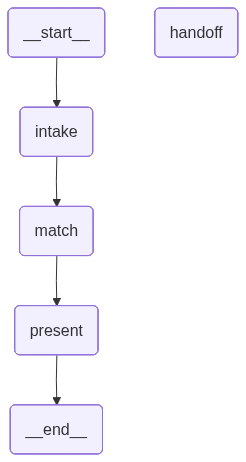

In [8]:
citizen_graph

## 방송 그래프 (마을 방송국)

지역 대표 프로필로 `DB.match` → 우리 지역 전용·고확신 제도 5건 선별 → `Send()` 로 제도별 멘트 병렬 생성 → 한 편의 마을 방송 대본으로 합칩니다(사투리 옵션). 코어(매칭·쉬운말)는 시민 그래프와 공유.

broadcast_graph compiled


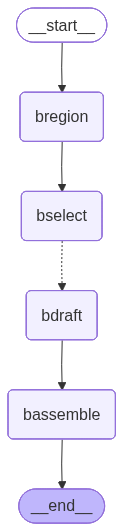

In [9]:
# === 방송 그래프(마을 방송국): workflow + Map-Reduce(Send) ===
REP_PROFILE = {
    "elderly_rural": {"age": 73, "income_band": "50", "characteristics": ["single_household", "farmer"]},
    "general":      {"age": 45, "income_band": "100", "characteristics": []},
}

def bregion(state: BroadcastState):
    demo = state.get("demographic", "elderly_rural")
    prof = dict(REP_PROFILE.get(demo, REP_PROFILE["general"]))
    prof["region_sido"] = (state["region"] or {}).get("sido")
    prof["region_sigungu"] = (state["region"] or {}).get("sigungu")
    prof["region"] = state["region"]
    return {"benefits": DB.match(prof, top=8)}

def bselect(state: BroadcastState):
    ranked = sorted(state["benefits"],
                    key=lambda c: (c["local"], c["confidence"] == "확실"), reverse=True)
    return {"benefits": ranked[:5]}

def fan_out(state: BroadcastState):
    return [Send("bdraft", {"benefit": b, "region": state["region"],
                            "demographic": state.get("demographic", "")})
            for b in state["benefits"]]

def bdraft(state: BroadcastState):
    b = state["benefit"]
    dialect = DIALECT_MAP.get((state["region"] or {}).get("sido"))
    sys = ("마을 스피커로 어르신들께 읽어드릴 30초 분량 복지 안내 멘트를 만드세요. "
           "짧고 또렷한 문장, 제도명·대상·신청처·문의 전화를 분명히. ")
    if dialect:
        sys += f"{dialect} 말투를 살짝 입혀 정겹게."
    text = (f"제도명:{b['service_name']} / 지원:{b['support']} / "
            f"접수처:{b['receiving_agency']} / 문의:{b['contact']}")
    seg = ask_llm([SystemMessage(content=sys), HumanMessage(content=text)]).content
    return {"segments": [f"📢 {seg}"]}

def bassemble(state: BroadcastState):
    region = state["region"]
    head = f"안녕하십니까, {region.get('sigungu','우리')} 주민 여러분. 오늘의 복지 소식입니다."
    tail = "이상 복지 소식이었습니다. 신청은 가까운 주민센터에서 도와드립니다. 고맙습니다."
    script = "\n\n".join([head] + state["segments"] + [tail])
    return {"script": script}

bb = StateGraph(BroadcastState)
bb.add_node("bregion", bregion)
bb.add_node("bselect", bselect)
bb.add_node("bdraft", bdraft)
bb.add_node("bassemble", bassemble)
bb.add_edge(START, "bregion")
bb.add_edge("bregion", "bselect")
bb.add_conditional_edges("bselect", fan_out, ["bdraft"])
bb.add_edge("bdraft", "bassemble")
bb.add_edge("bassemble", END)
broadcast_graph = bb.compile()
print("broadcast_graph compiled")
broadcast_graph

## Run — 시민 그래프 (해피패스)

대전 서구 어르신(1954년생·1인가구·기초수급·월세) 시나리오. **웹폼 payload** 를 초기 상태로 주입하므로 멀티턴 질문 없이 바로 매칭됩니다. 상담텍스트("당뇨·일자리")로 분야·키워드가 보강됩니다. 마지막에 '도와줘'로 복지사 핸드오프까지 시연. (실키 없으면 LLM/RPC 호출부에서 멈추니 env 먼저 채우세요.)

In [10]:
# === 시민 그래프 데모: interrupt 마다 스크립트된 답으로 자동 재개 ===
def run_citizen(initial, scripted, thread_id="demo-1"):
    cfg = {"configurable": {"thread_id": thread_id}, "callbacks": CALLBACKS}
    res = citizen_graph.invoke(initial, config=cfg)
    while "__interrupt__" in res:
        intr = res["__interrupt__"][0].value
        itype = intr.get("type")
        print(f"\n[AI] {intr.get('message','')}")
        if intr.get("rendered"):
            print(intr["rendered"])
        answer = scripted.get(itype)
        print(f"[사용자→{itype}] {answer}")
        res = citizen_graph.invoke(Command(resume=answer), config=cfg)
    print("\n=== 최종 상태 요약 ===")
    print("프로필:", res.get("profile"))
    print("추천 카드 수:", len(res.get("cards") or []))
    for m in res.get("messages", [])[-1:]:
        print("[AI]", getattr(m, "content", m))
    return res

initial = {
    "mode": "citizen",
    "messages": [HumanMessage(content="나도 받을 수 있는 복지가 있을까요?")],
    "form": {                       # 웹폼 payload (welfare_form_spec.md)
        "gender": "F", "birth_year": 1954, "income_band": "50",
        "region_sido": "대전광역시", "region_sigungu": "서구",
        "household_type": "single", "housing_type": "wolse",
        "checklist": ["basic_recipient", "single_parent"],
        "consult_text": "당뇨가 있고 일자리를 찾고 있어요",
    },
    "feedback_round": 0,
}
scripted = {
    "region_input": {"text": "대전광역시 서구"},                       # 폼에 지역 있으면 미발생
    "feedback": {"action": "help", "text": "신청을 어떻게 하는지 모르겠어요"},
    "handoff_approve": {"action": "send"},
}
_ = run_citizen(initial, scripted)


[AI] 추천을 보여드렸어요. ① 신청이 어려우면 '도와줘' ② 더 필요한 걸 말로 알려주시면 다시 찾아드려요 ③ 괜찮으면 '완료'.
[1] 취업 상담·알선 서비스 제공(종로 일자리플러스센터 운영)  (확실)
   - 지원: ○ 전문직업상담사와 1:1 맞춤형 취업상담   ○ 구직능력 향상을 위한 직업훈련 안내  ○ 양질의 일자리 발굴 및 취업알선  ○ 취업역량강화를 위한 컨설팅 및 교육  ○ 공공일자리 안내
   - 신청: 방문신청 / 접수처: 주민센터
   - 문의: 일자리정책과/02-2148-2304  마감: 상시신청
   - 자세히: https://www.gov.kr/portal/rcvfvrSvc/dtlEx/300000000149
[2] 종로구 동행일자리사업  (확실)
   - 지원: ○ 동행일자리사업 개요   저소득 취업취약 계층에게 지역사회에 필요한 공공일자리를 직접 제공하여 생계를 한시적으로 지원하고 자활 의지를 향상시켜 민간일자리로의 취업을 지원하는 사업입니다.     1. 신청방법    - 종로구민 : 주민등록 소재지 동주민센터 방문 신청    - 종로구민이 아닌 서울시민 : 가까운 종로구 내 동 주민센터 방문신청   2. 신청자격  사업 개시일 현재 만 18세 이상의 근로능력이 있는 서울시민으로서…
   - 신청: 방문신청 / 접수처: 주민센터
   - 문의: 종로구 일자리정책과/02-2148-2305  마감: 매년 5월 또는 11월
   - 자세히: https://www.gov.kr/portal/rcvfvrSvc/dtlEx/300000000164
[3] 충북형 도시농부 육성 사업  (확실)
   - 지원: ㅇ 인력이 부족한 농업인에게 도시농부 인력 지원  ㅇ 일손이 필요한 도시민에 농업 일자리 제공  ㅇ 농업인에게 도시농부 활용시 인건비의 40% 지원       (4시간 근무시 인건비 6만원 중 2.4만원 지원)  ㅇ 도시농부에게 농작업 장소까지 이동에 필요한 교통비 지원      (이동 거리에 따라 상이)  ㅇ 도시농부 교육 실비 및 상해

## Run — 방송 그래프

충남 예산군 고령·농촌 마을 방송 대본을 생성합니다.

In [11]:
bres = broadcast_graph.invoke(
    {"region": {"sido": "충청남도", "sigungu": "예산군"}, "demographic": "elderly_rural", "segments": []},
    config={"callbacks": CALLBACKS})
print(bres["script"])

안녕하십니까, 예산군 주민 여러분. 오늘의 복지 소식입니다.

📢 안녕하세요, 어르신들! 오늘은 어르신 복지 이용권에 대해 말씀드릴게요. 65세 이상 기초생활수급자와 차상위계층 무의탁 독거노인께서 이용하실 수 있는 제도입니다. 이 복지 이용권으로 목욕과 이미용 서비스를 지원해드려요. 단, 노인복지관이나 다른 기관에서 비슷한 서비스를 받고 계신 분들은 제외된답니다. 신청은 주민센터에서 하시면 되고, 궁금한 점은 123-4567로 전화해 주시면 됩니다. 많이 이용해 주세요!

📢 안녕하세요, 어르신들! 오늘은 의료취약계층 진료이송과 돌봄사업에 대해 말씀드릴게요. 이 사업은 보호자가 없어서 병원 진료나 퇴원 후 돌봄이 필요한 기초생활수급자와 차상위 계층을 위해 마련된답니다. 

병원 이송과 가사, 건강 돌봄을 지원해드려요. 신청은 예산군보건소 방문재활팀에 전화로 하시면 됩니다. 전화번호는 041-339-6091이에요. 

어르신들, 건강한 일상 회복을 위해 꼭 이용해보세요! 감사합니다!

📢 안녕하세요, 어르신들! 오늘은 농촌 찾아가는 왕진버스에 대해 말씀드릴게요. 이 제도는 협약병원 의료진이 직접 우리 읍면에 와서 양·한방 진료, 안과 및 치과 검진, 물리치료, 질병관리 예방교육, 그리고 돋보기 지원까지 해준답니다. 신청은 주민센터에서 하시면 되고요, 궁금한 점은 전북특별자치도 063-280-4196으로 전화해 주시면 됩니다. 어르신들, 건강 챙기세요!

📢 안녕하세요, 어르신들! 오늘은 국가유공상이자 분들을 위한 교통시설 이용 지원에 대해 말씀드릴게요. 

버스, 지하철, 내항여객선, 열차 등에서 무료 또는 할인 혜택을 받을 수 있답니다. 지원 내용은 상이등급에 따라 다르니, 자세한 건 보훈상담센터에 문의해 주이소. 

신분증을 제시하시면 되는데, 지하철은 국가보훈등록증이나 교통복지카드를 보여주시면 되고, 열차는 같은 증명서가 필요해요. 

신청은 주민센터에서 하시면 되고, 궁금한 점은 국가보훈부 보훈상담센터 1577-0606으로 전화해 주이소. 고맙습니다!



## Next steps

- **PII 미들웨어** — 핸드오프/로그에서 주민 개인정보 마스킹(정부 배포 전 필수).
- **핸드오프 실채널** — Slack/Gmail MCP 연동(전송은 HITL 승인 후, 개인정보 취급 동의 전제).
- **STT/TTS 어댑터** — 음성 입력(Whisper)·출력(CLOVA/ElevenLabs). 방송 대본 mp3화.
- **region_sido 보강** — 다수 지자체 사업의 `region_sido` 가 비어 '우리동네' 가점이 약함. `agency_name`/`service_name` 에서 지역 추출해 보강 권장.
- **Tavily 보강 노드** — 최신 개정·마감 freshness 체크.
- **운영 영속성** — `SqliteSaver`→`PostgresSaver`(다중 인스턴스).